In [1]:
from shearnet.core.dataset import generate_dataset, split_combined_images
from shearnet.utils.metrics import eval_ngmix, fork_eval_model

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import Optional
from shearnet.cli.evaluate import load_config, create_parser, initialize_model

In [2]:
SIGMA_FILL = 0.5
FLUX_FILL = 12258.97

def pad_to_four(arr, sigma=SIGMA_FILL, flux=FLUX_FILL):
    """
    Ensure arr has shape (N,4) with columns [g1, g2, sigma, flux].
    If arr is 1D (single sample), it becomes (1,4).
    If arr already has 4 columns, returns a copy.
    If arr has 3 columns, assumes the missing column is flux and appends flux.
    """
    arr = np.asarray(arr, dtype=float)

    # Convert single-sample 1D arrays to shape (1, ncols)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    if arr.ndim != 2:
        raise ValueError(f"pad_to_four expects 1D or 2D array, got ndim={arr.ndim}")

    nrows, ncols = arr.shape

    if ncols == 4:
        return arr.copy()
    if ncols > 4:
        raise ValueError(f"Array has {ncols} columns; expected at most 4.")

    needed = 4 - ncols
    # Decide pad values in order: append sigma then flux
    pad_vals = []
    if needed >= 1:
        # If both are missing (needed==2) we append sigma then flux.
        # If only one is missing (needed==1) we assume the last missing value is flux,
        # which is a common case (g1,g2,sigma -> missing flux).
        if needed == 2:
            pad_vals = [sigma, flux]
        else:  # needed == 1
            # Heuristic: assume missing value is flux (g1,g2,sigma -> missing flux).
            # If your case is different, change this to [sigma] instead.
            pad_vals = [flux]

    pad = np.tile(pad_vals, (nrows, 1))
    return np.concatenate([arr, pad], axis=1)

In [3]:
"""
Generate the dataset
"""

test_target_images, test_target_labels, obs = generate_dataset(
        samples=5000,
        psf_sigma=0.5,
        type='gauss',
        exp='ideal',
        seed=42,
        nse_sd=12.719674,
        npix=53,
        scale=0.141,
        return_psf=True,
        return_clean=False,
        return_obs=True,
    )

test_galaxy_images, test_psf_images = split_combined_images(test_target_images, has_psf=True, has_clean=False)

# labels = np.asarray(test_target_labels)
# labels_padded = pad_to_four(labels)

# Optional sanity check
assert test_target_labels.shape[1] == 4, \
    f"Padded shapes wrong:labels {test_target_labels.shape}"

100%|██████████| 5000/5000 [01:24<00:00, 59.20it/s]


In [4]:
"""
Analyze the predicted flux of ngmix
"""

ngmix_metrics = eval_ngmix(test_obs=obs, test_labels=test_target_labels, seed=42, psf_model='gauss', gal_model='gauss')

for i in range(0,10,1):
    print(test_target_labels[i])
print('VS')
for i in range(0,10,1):
    print(ngmix_metrics['preds'][i])

Starting NGmix ML fitting: num_gal: 5000 | psf_model: gauss | gal_model: gauss | num_cores: 96
[NaN Filter] Removed 429 rows with NaNs in predictions.

=== Combined Metrics (NGmix) ===
Mean Squared Error (MSE) from NGmix: 9.014038e+07
Average Bias from NGmix: 1.501906e+03
Time taken: 247.34 seconds

=== Per-Label Metrics ===
             g1: MSE = 2.446733e-02, Bias = -1.182439e-02
             g2: MSE = 2.437426e-02, Bias = +1.948373e-02
  g1g2_combined: MSE = 2.442079e-02, Bias = +3.829670e-03
          sigma: MSE = 9.582767e+00, Bias = +5.595120e-01
           flux: MSE = 3.605615e+08, Bias = +6.007055e+03

[ 7.9226442e-02 -2.7039587e-01  1.7022935e+00  1.2258970e+04]
[1.9511731e-01 2.4454683e-01 3.7562249e+00 1.2258970e+04]
[-5.0726914e-01 -3.3856666e-01  2.8675380e+00  1.2258970e+04]
[ 3.3238504e-02 -8.2223073e-02  3.3719413e+00  1.2258970e+04]
[-4.3683010e-03 -2.2179142e-01  1.8869891e+00  1.2258970e+04]
[2.2864348e-01 2.0222591e-01 2.5268762e+00 1.2258970e+04]
[1.7167982e-02 2.9

/home/adfield/ShearNet/shearnet/methods/ngmix.py:335: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(T / 2)


In [5]:
"""
Trying ShearNet
"""

parser = create_parser()
args = parser.parse_args(["--model_name", "second_validation_test", "--test_samples", "5000"])
config = load_config(args)

state = initialize_model(config, test_galaxy_images, test_psf_images)

nn_metrics = fork_eval_model(state=state, test_images=test_galaxy_images, test_psf_images=test_psf_images, test_labels=test_target_labels)

for i in range(0,10,1):
    print(test_target_labels[i])
print('VS')
for i in range(0,10,1):
    print(nn_metrics['all_preds'][i])


Loading model config from: /home/adfield/ShearNet/plots/second_validation_test/training_config.yaml

Evaluation Configuration

evaluation:
  test_samples: 30000
  seed: 58

model:
  process_psf: True
  type: fork-like
  galaxy: {'type': 'research_backed'}
  psf: {'type': 'forklens_psf'}

plotting:
  plot: True

comparison:
  mcal: True
  ngmix: True
  psf_model: gauss
  gal_model: gauss


Loading Model
Found 1 matching checkpoint(s):
  1. second_validation_test233

Loading checkpoint from: /home/adfield/ShearNet/model_checkpoint/second_validation_test233
✓ Model checkpoint loaded successfully

=== Combined Metrics (ShearNet) ===
Mean Squared Error (MSE) from ShearNet: 3.018818e-01
Average Bias from ShearNet: 4.213585e-01
Time taken: 6.21 seconds

=== Per-Label Metrics ===
             g1: MSE = 8.807400e-02, Bias = -7.308818e-02
             g2: MSE = 2.031358e-01, Bias = +4.504641e-01
  g1g2_combined: MSE = 1.456049e-01, Bias = +1.886880e-01
          sigma: MSE = 7.214763e-01, Bias 

/home/adfield/.conda/envs/shearnet_gpu/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/home/adfield/.conda/envs/shearnet_gpu/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/adfield/.conda/envs/shearnet_gpu/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/adfield/.conda/envs/shearnet_gpu/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/adfield/.conda/envs/shearnet_gpu/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/adfield/.conda

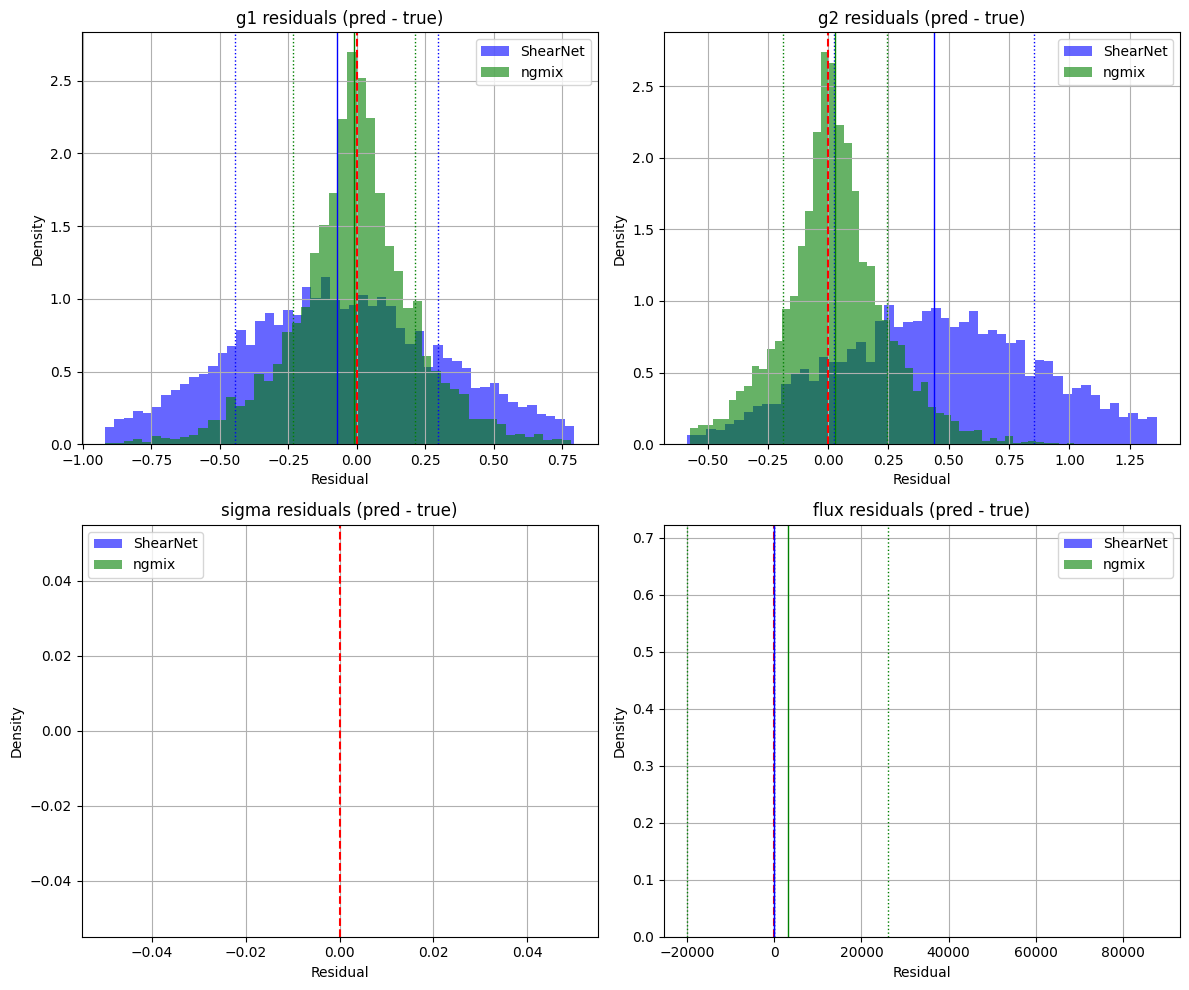

In [6]:
"""
Residual for shearnet
"""
from shearnet.utils.plot_helpers import plot_residuals

vals = np.array([0, 0, 0.5, 12258.97])
fake_metrics = np.tile(vals, (len(test_target_labels), 1))

# preds = np.asarray(nn_metrics['all_preds'])
# preds_padded = pad_to_four(preds)

plot_residuals(true_labels=test_target_labels,
               predicted_labels=nn_metrics['all_preds'],
               preds_ngmix=ngmix_metrics['preds'])